# Phase 5: Business Insights

Strategic recommendations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_8915/507908901.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_counts = df.groupby(['ChurnRisk', 'UpliftLevel']).size().unstack(fill_value=0)


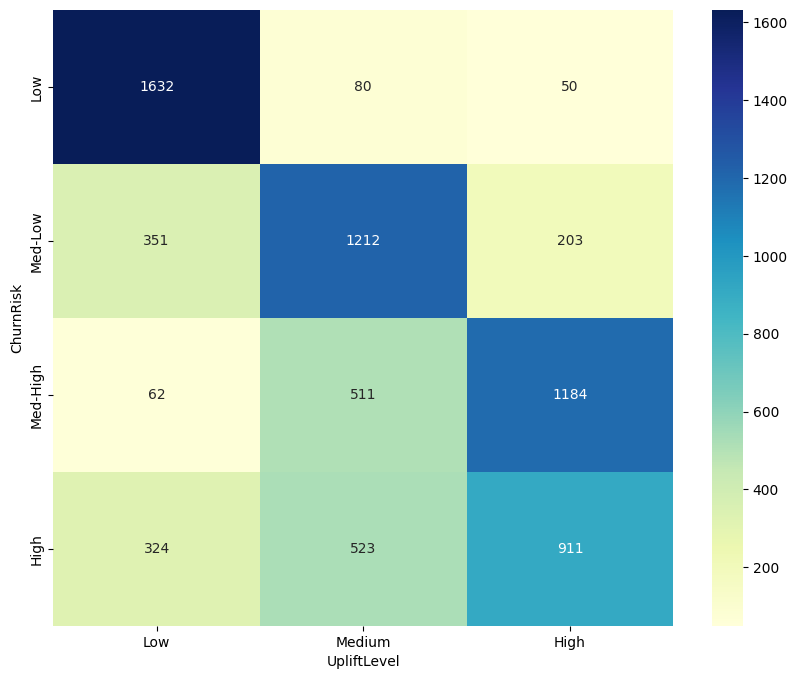

In [2]:
df = pd.read_csv('../data/processed_with_uplift.csv')
df['ChurnRisk'] = pd.qcut(df['MonthlyCharges'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
df['UpliftLevel'] = pd.qcut(-df['UpliftScore'], q=3, labels=['Low', 'Medium', 'High'])
segment_counts = df.groupby(['ChurnRisk', 'UpliftLevel']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 8))
sns.heatmap(segment_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.savefig('../results/segmentation_heatmap.png')
plt.show()


In [3]:
target_group = df[(df['ChurnRisk'] == 'High') & (df['UpliftLevel'] == 'High')]
print(f'Target Segment Size: {len(target_group)}')
print(f"Expected Reduction in Churn for Target: {-target_group['UpliftScore'].mean()*100:.2f} percentage points")


Target Segment Size: 911
Expected Reduction in Churn for Target: 25.14 percentage points
